# Detecção de Anomalias com Isolation Forest

Este notebook consome os dados tratados da camada Gold para identificar transações com valores atípicos em relação à média.

# Importações

In [14]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração para os gráficos
sns.set_theme(style="whitegrid")

# Observando linhas e colunas da camada Gold

In [15]:
import pandas as pd

df = pd.read_parquet('../gold/camada_gold.parquet')

print(df.head())

                                   HASH_CPF_PORTADOR  QTD_TRANSACOES  \
0  000edd7142e0a18d234c19e52222ad8fa27230eab85cca...               4   
1  0044817ad2e2f83f9f53d70c07731412d0c4880b13d7aa...               7   
2  0048938b883fdd9eb27e4021a1e0e9e87d389933382be1...               1   
3  009d7a3b99570625c93525120c3905601245c6142d5268...               4   
4  00b8a6cc4636fded01e21620f7e2a04c427d472a0db3f3...               9   

   VOLUME_TOTAL  TICKET_MEDIO  VOLATILIDADE_STD  PCT_SAQUES  PCT_COMPRAS  \
0        116.51     29.127500         27.437647         0.0          1.0   
1        608.40     86.914286         94.219432         0.0          1.0   
2        499.00    499.000000          0.000000         0.0          1.0   
3       1568.54    392.135000        276.111327         0.0          1.0   
4      12991.14   1443.460000        964.362100         0.0          1.0   

   PCT_SIGILO  QTD_TRANSACOES_LOG  VOLUME_TOTAL_LOG  TICKET_MEDIO_LOG  \
0         0.0            1.609438    

# Seleção de features preparadas

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Alimentando o modelo

features_modelos = [
    'QTD_TRANSACOES_LOG_SCALED',
    'VOLUME_TOTAL_LOG_SCALED',
    'TICKET_MEDIO_LOG',
    'VOLATILIDADE_STD_LOG',
    'PCT_SAQUES',
    'PCT_SIGILO'
]

# Conferindo se tem valor nulo nas variáveis de treino
df[features_modelos] = df[features_modelos].fillna(0)

# Instanciamento e treinamento do Isolation Forest

In [17]:
# Orienta o modelo a marcar o top 1% mais anômalo

modelo = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# O modelo avalia cada portador e retorna 1 ou -1 

df['score_anomalia'] = modelo.fit_predict(df[features_modelos])

# Tradução de -1 para True (é anomalia) para o filtro

df['alerta_fraude'] = df['score_anomalia'] == -1

print(df['alerta_fraude'].value_counts())

alerta_fraude
False    2781
True       29
Name: count, dtype: int64


# Visualização do comportamento atípico

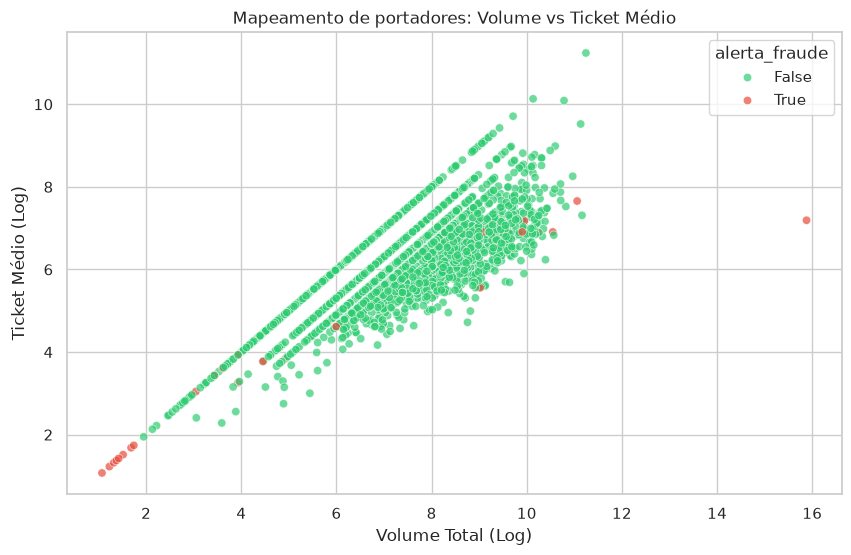

In [20]:
plt.figure(figsize=(10, 6))

# Plotando o volume total vs ticket médio 

sns.scatterplot(
    data=df,
    x='VOLUME_TOTAL_LOG',
    y='TICKET_MEDIO_LOG',
    hue='alerta_fraude',
    palette={False: '#2ecc71', True: '#e74c3c'},
    alpha=0.7

)

plt.title('Mapeamento de portadores: Volume vs Ticket Médio')
plt.xlabel('Volume Total (Log)')
plt.ylabel('Ticket Médio (Log)')
plt.show()

# Auditoria dos casos isolados

In [19]:
# Filtrando apenas os portadores anômalos e trazendo as colunas para leitura

portadores_suspeitos = df[df['alerta_fraude']].sort_values(by='VOLUME_TOTAL', ascending=False)

colunas_auditoria = [
    'HASH_CPF_PORTADOR',
    'QTD_TRANSACOES',
    'VOLUME_TOTAL',
    'TICKET_MEDIO',
    'PCT_SAQUES',
    'PCT_SIGILO'
]

display(portadores_suspeitos[colunas_auditoria].head(10))

,HASH_CPF_PORTADOR,QTD_TRANSACOES,VOLUME_TOTAL,TICKET_MEDIO,PCT_SAQUES,PCT_SIGILO
1717,HASH_NAO_INFORMADO,5934,7871500.64,1326.508365,0.000000,1.0
2059,bef51bb3efe382350b888e70397392e1040d088003a39b...,30,63429.90,2114.330000,0.200000,0.0
884,53bc0c4ee5c5ecbfe809625dc146832f5a3634901b6c85...,38,38000.00,1000.000000,1.000000,0.0
1533,8e47d2a453d5026bd08c24e2130cb5cb570a557d1eccc8...,28,27800.00,992.857143,1.000000,0.0
631,3e1e5868c7a92ad903d93ceaa056466cbee13c3e45f7ef...,16,20950.76,1309.422500,1.000000,0.0
2596,eda59412be9be5539c447294b36ed2be91a25a48e9e4c2...,20,20000.00,1000.000000,1.000000,0.0
993,5d6b50db49b6d6b513c43df0b659472d19e8e24da91eb8...,15,14990.00,999.333333,1.000000,0.0
1080,6495178ea1fc669f9d927c1ed8b52c0e7626dfea3b6856...,11,10999.27,999.933636,0.909091,0.0
1196,703c688c7a2b4fcb3272336c3a53ea82f6ece388e2642c...,8,9790.78,1223.847500,1.000000,0.0
1953,b6340de8120b206b17afe757d357c35f86c5d082aeb369...,9,9000.00,1000.000000,1.000000,0.0
